In [1]:
import os
os.environ['VISIBLE_CUDA_DEVICES'] = '0'
# os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
from pprint import pprint
import pickle as pkl

from tqdm.auto import tqdm
import numpy as np

import torch
import torch.optim as optim
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'torch device: {device}')

# GNN package
from torch_geometric.loader import DataLoader
import networkx as nx

# Visualization
import matplotlib.pyplot as plt

torch device: cuda


/home/alan/miniconda3/envs/seg_match/lib/python3.9/site-packages/torch_geometric/typing.py:31: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/alan/miniconda3/envs/seg_match/lib/python3.9/site-packages/torch_scatter/_scatter_cpu.so: undefined symbol: _ZN3c106SymInt19promote_to_negativeEv
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


In [2]:
from solo2graph import Graph, PairedGraph
from dataset import CustomDataset, transform_data
from models import CustomModel
from losses import CustomCriterion
from eva import compute_eval

/home/alan/miniconda3/envs/seg_match/lib/python3.9/site-packages/diffusers/models/cross_attention.py:30: FutureWarning: Importing from cross_attention is deprecated. Please import from diffusers.models.attention_processor instead.
  deprecate(


torch device: cuda


In [3]:
SOLO_NAME =  'poisson5r16'
SCENE = 'SimpleOffice'
# SOLO_NAME = 'D_pois3r8'
# SCENE = 'WP16'
DATA_DIR = f'data/{SCENE}/{SOLO_NAME}/paired_graph'
CKPT_DIR = f'ckpt/{SCENE}/{SOLO_NAME}'
if not os.path.exists(CKPT_DIR):
    os.makedirs(CKPT_DIR)

In [4]:
ds = CustomDataset(root=DATA_DIR, transform=transform_data)
dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
dc = next(iter(dl))

In [5]:
dc['edge_index'].shape

torch.Size([1, 2, 1236])

In [6]:
# ds = CustomDataset(root=DATA_DIR, scene=SCENE)
# ds[0]['node_df'].columns

In [7]:
# # e1is = []
# len_e2 = []
# for dc in iter(dl):
#   e1is.append(len(dc['e1i'][0]))
#   len_e2.append(len(dc['e2i'][0]) + len(dc['e2j'][0]))

# len_e2 = np.array(len_e2)
# for k in [1, 3, 5]:
#   p_rand = np.clip(1 - (len_e2 - k) / len_e2, 0, 1)
#   print(f'rand hits@{k}: {p_rand.mean():.4f}, {p_rand.std():.4f}')

In [8]:
node_attr_dim = 1#dc['node_attr'].shape[2]
# node_visual_dim = dc['bbox_embs'].shape[2]
edge_attr_dim = dc['edge_attr'].shape[2]
emb_dim = 64

print(f'node attr dim: {node_attr_dim}')
# print(f'node visual dim: {node_visual_dim}')
print(f'edge attr dim: {edge_attr_dim}')
print(f'emb dim: {emb_dim}')

node attr dim: 1
edge attr dim: 3
emb dim: 64


In [9]:
ds = CustomDataset(root=DATA_DIR, transform=transform_data)

# random select 1000 samples from ds
ds = torch.utils.data.Subset(ds, np.random.choice(len(ds), 1000, replace=False))

# Do not use batch_size>1 for now, it will crash the e1i, e1j, e2i, e2j indices
train_ds, eval_ds, test_ds = torch.utils.data.random_split(ds, [0.5, 0.2, 0.3], generator=torch.Generator().manual_seed(42))
train_dl = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
eval_dl = DataLoader(eval_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

print('train size:', len(train_ds))
print('eval size:', len(eval_ds))
print('test size:', len(test_ds))

train size: 500
eval size: 200
test size: 300


In [10]:
def data_dict_to_device(data_dict, device):
    for k in data_dict:
        if isinstance(data_dict[k], torch.Tensor):
            data_dict[k] = data_dict[k].to(device)
    return data_dict

In [11]:
def train_step(model, data_dict, optimizer, criterion):
    data_dict = data_dict_to_device(data_dict, device)
    model.train()
    optimizer.zero_grad()
    pred_dict = model(data_dict)
    loss = criterion(pred_dict, data_dict)
    loss.backward()
    optimizer.step()
    return loss.item()

In [12]:
def eval_step(model, data_dict, criterion):
    data_dict = data_dict_to_device(data_dict, device)
    model.eval()
    with torch.no_grad():
        pred_dict = model(data_dict)
        loss = criterion(pred_dict, data_dict)
    metrics = compute_eval(pred_dict, data_dict)
    return loss.item(), metrics

In [13]:
model = CustomModel(node_attr_dim, edge_attr_dim, emb_dim, match_threshold=0.2).to(device)
criterion = CustomCriterion(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

e = 0
history = {'train_loss': [], 'eval_loss': [], 'eval_metrics': []}

In [15]:
# training loop
for _ in tqdm(range(100)):
    e += 1
    train_loss = 0
    for data_dict in train_dl:
        train_loss += train_step(model, data_dict, optimizer, criterion)
    train_loss /= len(train_dl)

    if e % 1 == 0:
        mean_metrics = {}
        sum_eval_loss = 0

        with torch.no_grad():
            model.eval()
            for data_dict in eval_dl:
                eval_loss, metrics = eval_step(model, data_dict, criterion)
                sum_eval_loss += eval_loss
                for k, v in metrics.items():
                    if k in mean_metrics:
                        mean_metrics[k] = mean_metrics.get(k, 0) + v 
                    else:
                        mean_metrics[k] = v

        for k, v in mean_metrics.items():
            mean_metrics[k] = v / len(eval_dl)
        eval_loss = sum_eval_loss / len(eval_dl)

        torch.save(model.state_dict(), f'{CKPT_DIR}/model_{e}.pth')

        history['train_loss'].append(train_loss)
        history['eval_loss'].append(eval_loss)
        history['eval_metrics'].append(mean_metrics)
        print(f'----- epoch: {e} -----')
        
        print(f'train loss: {train_loss:.6f}')
        print(f'eval  loss: {eval_loss:.6f}')
        print('eval metrics:')
        for k, v in mean_metrics.items():
            print(f'{k}: {v:.4f}')
        print()

plt.plot(history['train_loss'], label='train loss')
plt.plot(history['eval_loss'], label='eval loss')
plt.legend()
plt.figure()
for k, v in history['eval_metrics'][0].items():
    plt.plot([x[k] for x in history['eval_metrics']], label=f'eval {k}')
plt.legend()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

----- epoch: 3 -----
train loss: 1.207558
eval  loss: 1.189578
eval metrics:
acc: 0.6172
pre: 0.1563
rec: 0.0341
f1: 0.0517

----- epoch: 4 -----
train loss: 1.108811
eval  loss: 1.166595
eval metrics:
acc: 0.6257
pre: 0.3281
rec: 0.0717
f1: 0.1048

----- epoch: 5 -----
train loss: 1.052357
eval  loss: 1.098501
eval metrics:
acc: 0.6290
pre: 0.3703
rec: 0.0863
f1: 0.1242

----- epoch: 6 -----
train loss: 1.003811
eval  loss: 1.064547
eval metrics:
acc: 0.6343
pre: 0.4016
rec: 0.1020
f1: 0.1432

----- epoch: 7 -----
train loss: 0.967851
eval  loss: 1.084157
eval metrics:
acc: 0.6308
pre: 0.4140
rec: 0.1135
f1: 0.1579

----- epoch: 8 -----
train loss: 0.942745
eval  loss: 1.023877
eval metrics:
acc: 0.6383
pre: 0.4403
rec: 0.1280
f1: 0.1770

----- epoch: 9 -----
train loss: 0.916236
eval  loss: 1.013770
eval metrics:
acc: 0.6433
pre: 0.4774
rec: 0.1298
f1: 0.1839

----- epoch: 10 -----
train loss: 0.894173
eval  loss: 1.023182
eval metrics:
acc: 0.6420
pre: 0.4843
rec: 0.1455
f1: 0.2016


KeyboardInterrupt: 

In [ ]:
# model.load_state_dict(torch.load(f'ckpt/{SCENE}/{SOLO_NAME}/model_200.pth'))

<All keys matched successfully>

### Has overlapping


In [16]:
mean_metrics = {}
sum_test_loss = 0
gid2pred = {}

with torch.no_grad():
    model.eval()
    for data_dict in tqdm(test_dl):
        test_loss, metrics = eval_step(model, data_dict, criterion)
        sum_test_loss += test_loss

        pred_dict = model(data_dict) 

        g1_step = data_dict['g1_step'][0].item()
        if g1_step not in gid2pred:
            gid2pred[g1_step] = {'pred': [pred_dict], 'data': [data_dict]}
        else:
            gid2pred[g1_step]['pred'].append(pred_dict)
            gid2pred[g1_step]['data'].append(data_dict)

        for k, v in metrics.items():
            if k in mean_metrics:
                mean_metrics[k] = mean_metrics[k] + v
            else:
                mean_metrics[k] = v
        


for k, v in mean_metrics.items():
    mean_metrics[k] = v / len(test_dl)

mean_test_loss = sum_test_loss / len(test_dl)
print(f'mean_test loss: {mean_test_loss:.4f}')
print('test metrics:')
for k, v in mean_metrics.items():
    print(f'{k}: {v:.4f}')

  0%|          | 0/300 [00:00<?, ?it/s]

mean_test loss: 0.9313
test metrics:
acc: 0.6769
pre: 0.5178
rec: 0.1924
f1: 0.2579


In [17]:
res = []

for gid, v in gid2pred.items():
    g1_pose = v['data'][0]['g1_camera_pose'][0]
    g1_step = v['data'][0]['g1_step'][0].item()

    pred = []

    gt_pose = None
    gt_step = -1
    gt_pos_loss = np.inf
    gt_q_loss = np.inf

    for idx in range(len(v['pred'])):
        pred_dict = v['pred'][idx]
        data_dict = v['data'][idx]

        g1_pose = data_dict['g1_camera_pose'][0].cpu()
        g1_step = data_dict['g1_step'][0].item()
        g2_pose = data_dict['g2_camera_pose'][0].cpu()
        g2_step = data_dict['g2_step'][0].item()

        # pred
        match_mask = (pred_dict['matches0'] != -1)
        if sum(match_mask) == 0:
            score = -np.inf
            continue
        else:
            match_score = pred_dict['matching_scores0'][match_mask].sort(descending=True)[0]
            score = torch.mean(match_score).item()
        pred.append((g2_step, score, g2_pose.numpy()))

        # gt
        pos_loss = np.linalg.norm(g1_pose[:3] - g2_pose[:3]).item()
        q_loss = np.linalg.norm(g1_pose[3:] - g2_pose[3:]).item()
        if pos_loss < gt_pos_loss:
            gt_pos_loss = pos_loss
            gt_q_loss = q_loss
            gt_pose = g2_pose.numpy()
            gt_step = g2_step
        if pos_loss == gt_pos_loss and q_loss < gt_q_loss:
            gt_pos_loss = pos_loss
            gt_q_loss = q_loss
            gt_pose = g2_pose.numpy()
            gt_step = g2_step

    pred = sorted(pred, key=lambda x: x[1], reverse=True)


    # print(f'g1_step: {g1_step}')
    # print(f'gt_step: {gt_step}')
    # print(f'pred: {[p[0] for p in pred]}')
    # print()
    res.append({
        'g1_step': g1_step, 
        'gt_step': gt_step,
        'gt_pose': gt_pose,
        'pred': pred,
    })


def compute_hits_at_k(gt, pred, k):
    gt_pose = gt
    for i in range(min(len(pred), k)):
        if np.allclose(gt_pose, pred[i][2]) and i < k:
            return True
    return False

res = sorted(res, key=lambda x: x['g1_step'])

mean_len_of_pred = np.mean([len(d['pred']) for d in res])
std_len_of_pred = np.std([len(d['pred']) for d in res])
max_len_of_pred = np.max([len(d['pred']) for d in res])
print(f'mean_len_of_pred: {mean_len_of_pred:.4f}')
print(f'std_len_of_pred: {std_len_of_pred:.4f}')
print(f'max_len_of_pred: {max_len_of_pred:.4f}')
print()

n_data = len(res)
n_no_match = sum([len(d['pred']) == 0 for d in res])
n_has_match = n_data - n_no_match
n_hits_at_1 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 1) for d in res])
n_hits_at_3 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 3) for d in res])
n_hits_at_5 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 5) for d in res])
n_hits_at_10 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 10) for d in res])
print(f'data len: {n_data}')
print(f'num of has , no matches: {n_has_match} , {n_no_match}')
print(f'hits@1: {n_hits_at_1 / (n_has_match) * 100:.4f}%')
print(f'hits@3: {n_hits_at_3 / (n_has_match) * 100:.4f}%')
print(f'hits@5: {n_hits_at_5 / (n_has_match) * 100:.4f}%')
print(f'hits@10: {n_hits_at_10 / (n_has_match) * 100:.4f}%')

mean_len_of_pred: 2.3107
std_len_of_pred: 1.5139
max_len_of_pred: 8.0000

data len: 103
num of has , no matches: 96 , 7
hits@1: 65.6250%
hits@3: 92.7083%
hits@5: 100.0000%
hits@10: 100.0000%


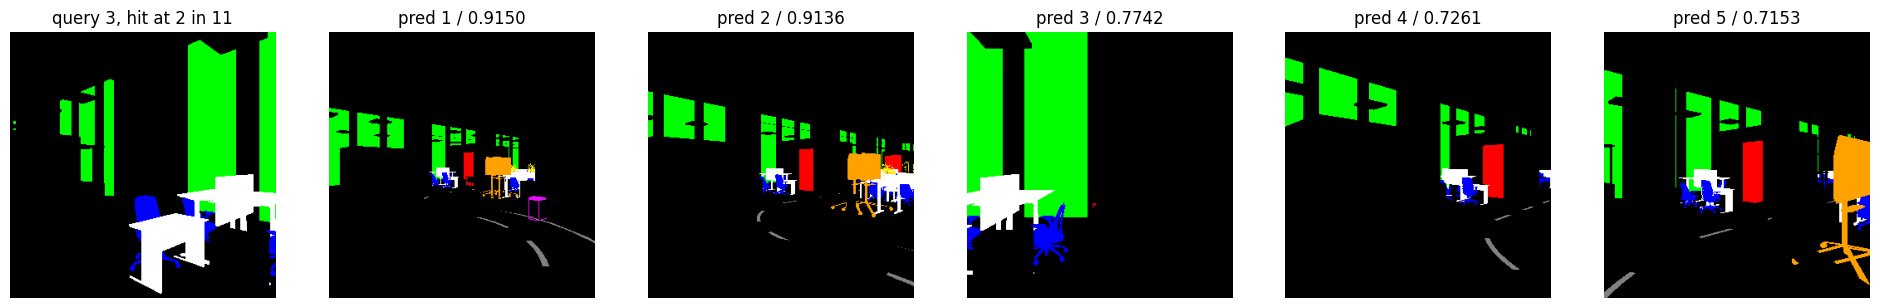

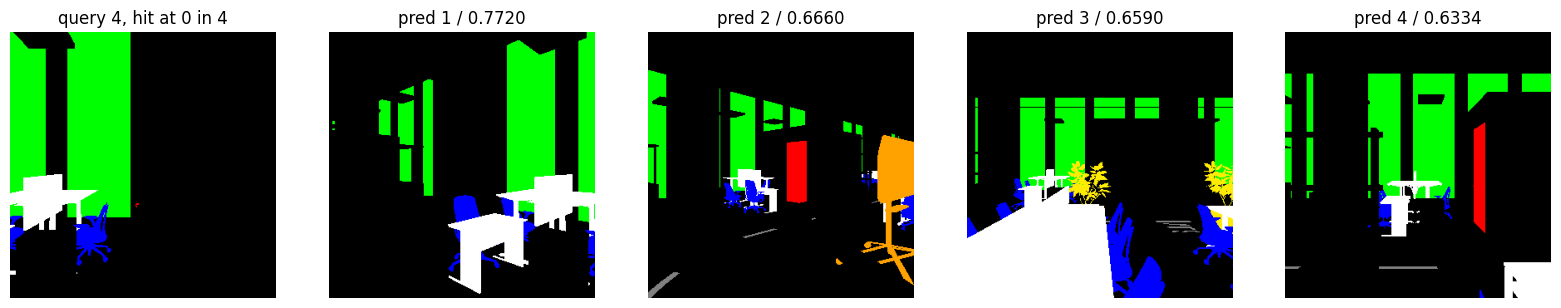

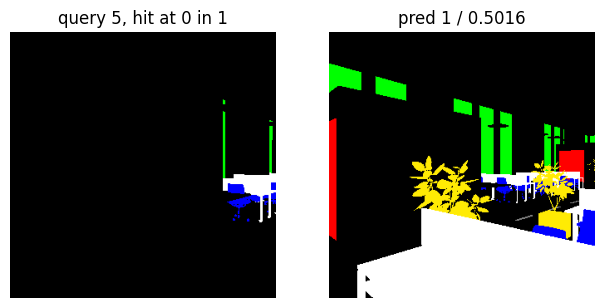

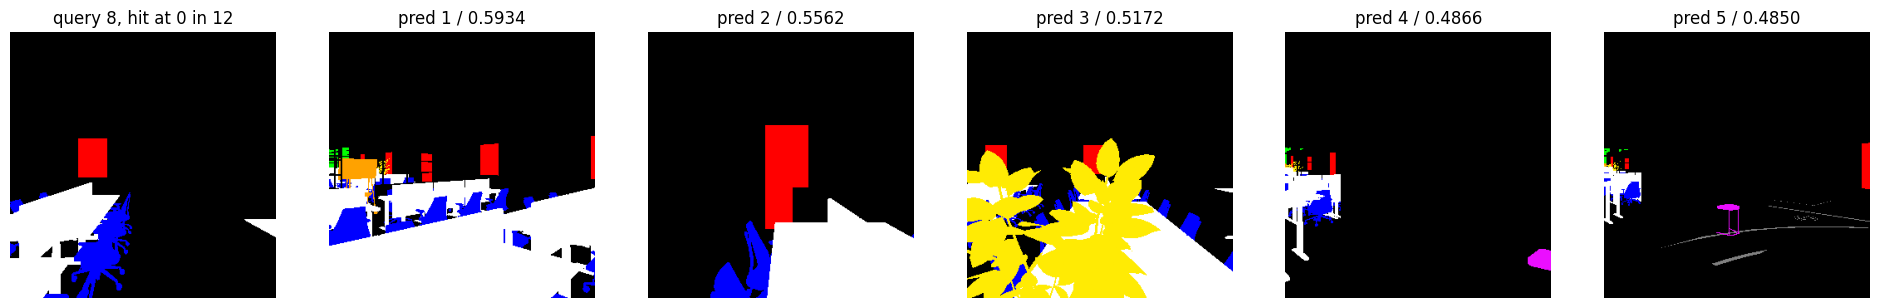

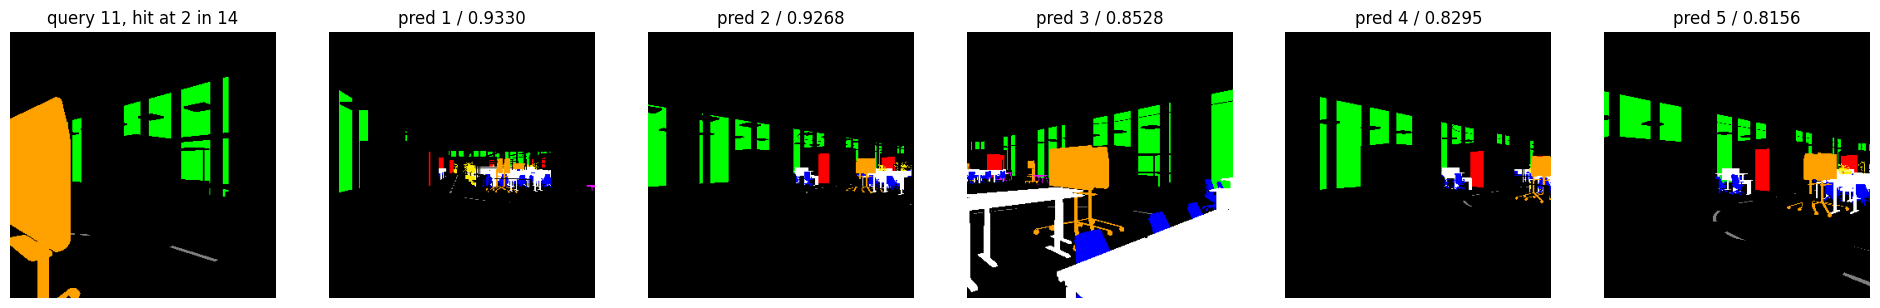

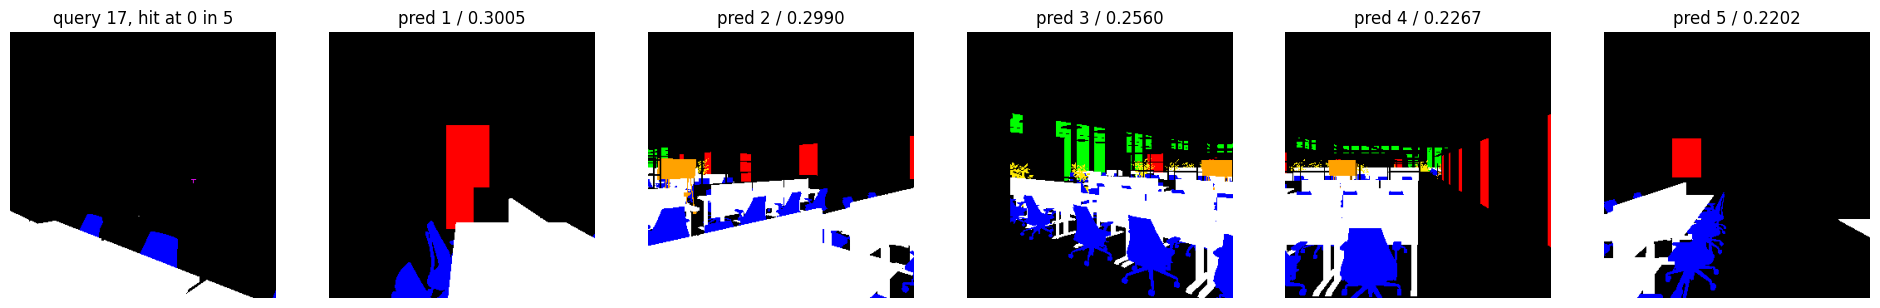

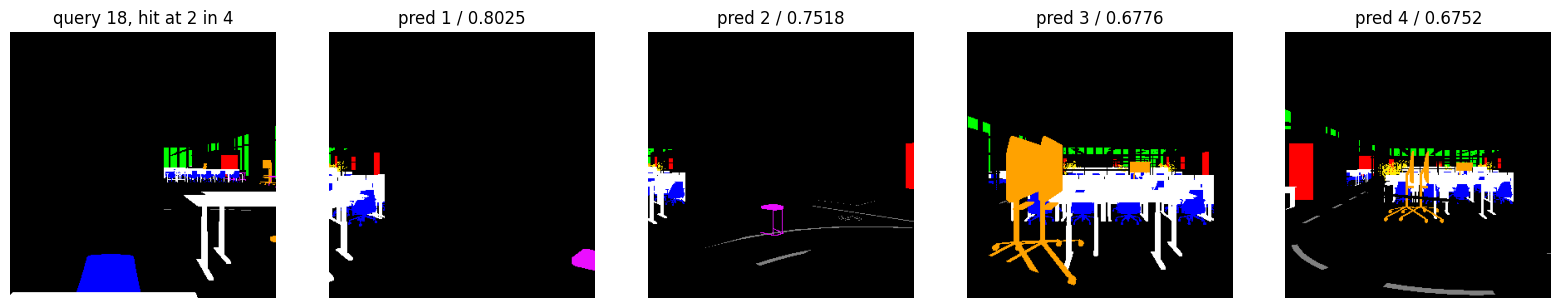

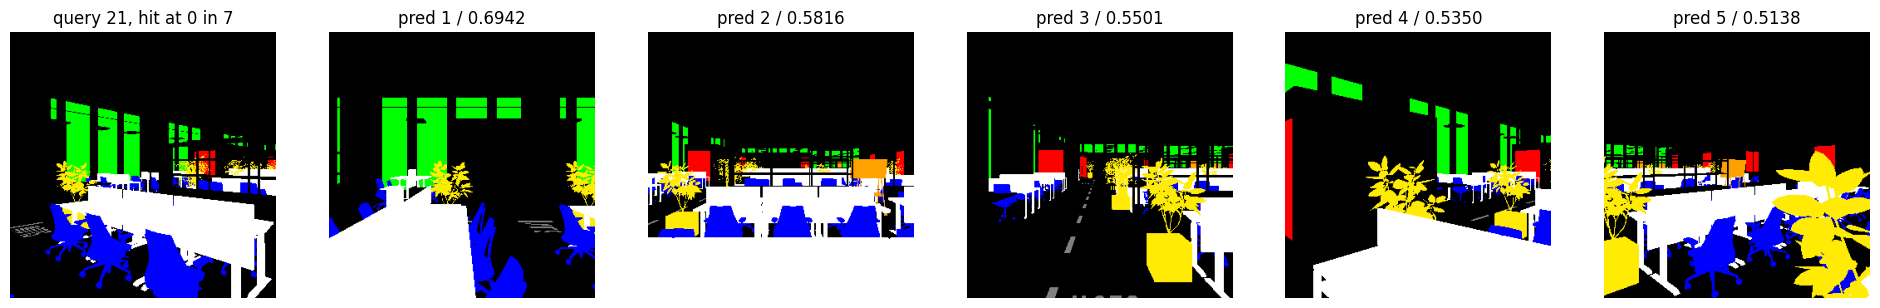

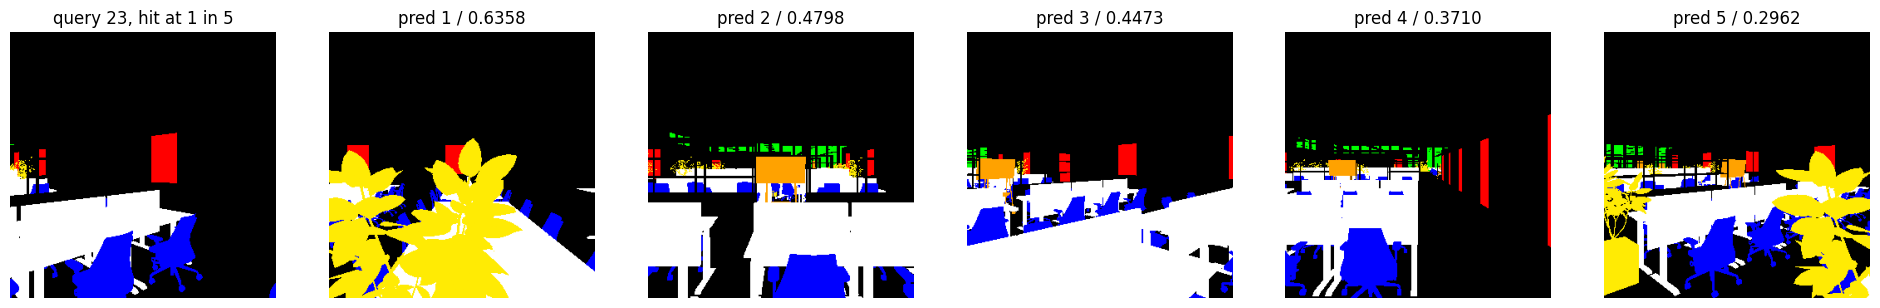

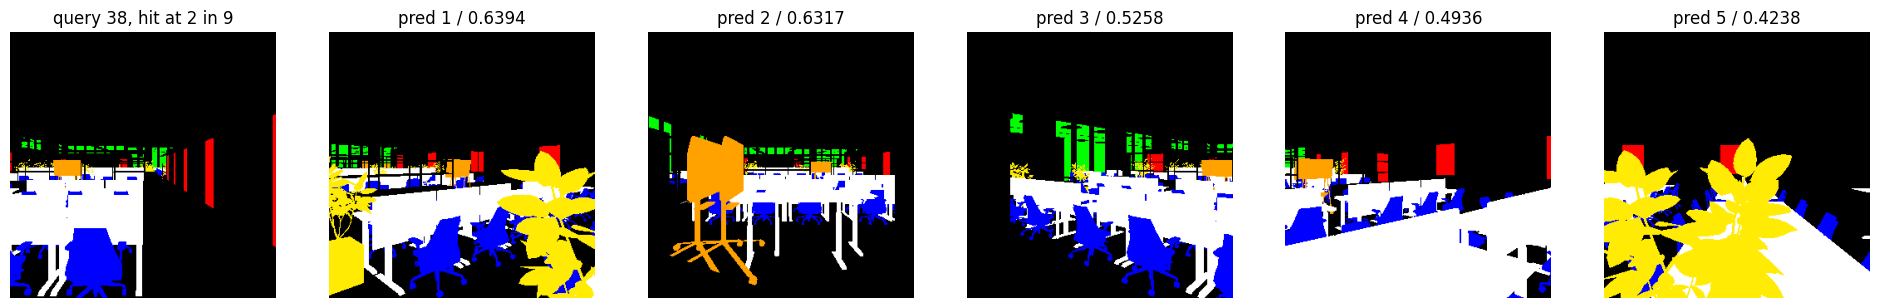

In [ ]:
# idx = 2 # [2, 3, 4, 7, 15, 30, 37, 61, 62, 81, 93]
# for idx in range(100):
#     if compute_hits_at_k(res[idx]['gt_pose'], res[idx]['pred'], 1) == True:
#         print(idx)

def gen_vis_data(res, idx, k, max_len=5, vis_type='seg'):
    g1_step = res[idx]['g1_step']
    pred_g2_steps = [d[0] for d in res[idx]['pred']]
    pred_g2_score = [d[1] for d in res[idx]['pred']]

    plt.figure(figsize=(24, 6))
    plt.subplot(1, max_len+1, 1)
    plt.axis('off')
    plt.title(f'query {g1_step}, hit at {k} in {len(pred_g2_steps)}')
    plt.imshow(read_img(g1_step, vis_type))

    for i in range(min(max_len, len(pred_g2_steps))):
        plt.subplot(1, max_len+1, i + 2)
        plt.axis('off')
        plt.title(f'pred {i + 1} / {pred_g2_score[i]:.4f}')
        plt.imshow(read_img(pred_g2_steps[i], vis_type))

    return g1_step, pred_g2_steps, pred_g2_score

def read_img(step, type='rgb'):
    if type == 'rgb':
        suffix = ''
    elif type == 'inst':
        suffix = '.instance segmentation' 
    elif type == 'seg':
        suffix = '.semantic segmentation'
    else:
        print('vis type error')
    path = f'data/{SCENE}/{SOLO_NAME}/sequence.0/step{step}.camera{suffix}.png'
    img = plt.imread(path)
    return img

i = 0
cnt = 0
range_min = 0
range_max = 3
while cnt < 10:
    gt_pose = res[i]['gt_pose']
    pred = res[i]['pred']
    pred_g2_poses = [d[2] for d in pred]
    k = -1
    # print(f'gt_pose: {gt_pose[:3]}')
    # print(f'pred_pose: {pred_g2_poses[0][:3]}')
    for k, pred_pose in enumerate(pred_g2_poses):
        if np.allclose(gt_pose, pred_pose):
            # print(f'idx: {i}, hit at {k} over {len(pred)}')
            # print()
            break
    if range_min <= k < range_max:
        cnt += 1
        _ = gen_vis_data(res, i, k, max_len=5, vis_type='seg')
    i += 1

### all pairs


In [ ]:
mean_metrics = {}
sum_test_loss = 0
gid2pred = {}

with torch.no_grad():
    model.eval()
    for data_dict in tqdm(test_dl):
        test_loss, metrics = eval_step(model, data_dict, criterion)
        sum_test_loss += test_loss

        pred_dict = model(data_dict) 

        g1_step = data_dict['g1_step'][0].item()
        if g1_step not in gid2pred:
            gid2pred[g1_step] = {'pred': [pred_dict], 'data': [data_dict]}
        else:
            gid2pred[g1_step]['pred'].append(pred_dict)
            gid2pred[g1_step]['data'].append(data_dict)

        for k, v in metrics.items():
            if k in mean_metrics:
                mean_metrics[k] = mean_metrics[k] + v
            else:
                mean_metrics[k] = v
        


for k, v in mean_metrics.items():
    mean_metrics[k] = v / len(test_dl)

mean_test_loss = sum_test_loss / len(test_dl)
print(f'mean_test loss: {mean_test_loss:.4f}')
print('test metrics:')
for k, v in mean_metrics.items():
    print(f'{k}: {v:.4f}')

  0%|          | 0/15840 [00:00<?, ?it/s]

mean_test loss: inf
test metrics:
acc: 0.8794
pre: 0.3220
rec: 0.3418
f1: 0.2994


In [ ]:
res = []

for gid, v in gid2pred.items():
    g1_pose = v['data'][0]['g1_camera_pose'][0]
    g1_step = v['data'][0]['g1_step'][0].item()

    pred = []

    gt_pose = None
    gt_step = -1
    gt_pos_loss = np.inf

    for idx in range(len(v['pred'])):
        pred_dict = v['pred'][idx]
        data_dict = v['data'][idx]

        g1_pose = data_dict['g1_camera_pose'][0].cpu()
        g1_step = data_dict['g1_step'][0].item()
        g2_pose = data_dict['g2_camera_pose'][0].cpu()
        g2_step = data_dict['g2_step'][0].item()

        # pred
        match_mask = (pred_dict['matches0'] != -1)
        if sum(match_mask) == 0:
            score = -np.inf
            continue
        else:
            match_score = pred_dict['matching_scores0'][match_mask].sort(descending=True)[0]
            score = torch.mean(match_score).item()
        pred.append((g2_step, score, g2_pose.numpy()))

        # gt
        pos_loss = np.linalg.norm(g1_pose - g2_pose).item()
        if pos_loss < gt_pos_loss:
            gt_pos_loss = pos_loss
            gt_pose = g2_pose.numpy()
            gt_step = g2_step

    pred = sorted(pred, key=lambda x: x[1], reverse=True)


    # print(f'g1_step: {g1_step}')
    # print(f'gt_step: {gt_step}')
    # print(f'pred: {[p[0] for p in pred]}')
    # print()
    res.append({
        'g1_step': g1_step, 
        'gt_step': gt_step,
        'gt_pose': gt_pose,
        'pred': pred,
    })


def compute_hits_at_k(gt, pred, k):
    gt_pose = gt
    for i in range(min(len(pred), k)):
        if np.allclose(gt_pose, pred[i][2]) and i < k:
            return True
    return False

res = sorted(res, key=lambda x: x['g1_step'])

mean_len_of_pred = np.mean([len(d['pred']) for d in res])
std_len_of_pred = np.std([len(d['pred']) for d in res])
max_len_of_pred = np.max([len(d['pred']) for d in res])
print(f'mean_len_of_pred: {mean_len_of_pred:.4f}')
print(f'std_len_of_pred: {std_len_of_pred:.4f}')
print(f'max_len_of_pred: {max_len_of_pred:.4f}')
print()

n_data = len(res)
n_no_match = sum([len(d['pred']) == 0 for d in res])
n_has_match = n_data - n_no_match
n_hits_at_1 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 1) for d in res])
n_hits_at_3 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 3) for d in res])
n_hits_at_5 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 3) for d in res])
n_hits_at_10 = sum([compute_hits_at_k(d['gt_pose'], d['pred'], 10) for d in res])
print(f'data len: {n_data}')
print(f'num of has , no matches: {n_has_match} , {n_no_match}')
print(f'hits@1: {n_hits_at_1 / (n_has_match) * 100:.4f}%')
print(f'hits@3: {n_hits_at_3 / (n_has_match) * 100:.4f}%')
print(f'hits@5: {n_hits_at_5 / (n_has_match) * 100:.4f}%')
print(f'hits@10: {n_hits_at_10 / (n_has_match) * 100:.4f}%')

mean_len_of_pred: 154.3765
std_len_of_pred: 23.4144
max_len_of_pred: 186.0000

data len: 85
num of has , no matches: 85 , 0
hits@1: 1.1765%
hits@3: 3.5294%
hits@5: 3.5294%
hits@7: 4.7059%
hits@10: 5.8824%


In [1]:
data_dict = list(iter(test_dl))[10]
data_dict_to_device(data_dict, device)
pred_dict = model(data_dict)
# cam_pose = data_dict['g1_camera_pose']

with torch.no_grad():
    metrics = compute_eval(pred_dict, data_dict)
    for k, v in metrics.items():
        if type(v) == torch.Tensor:
            metrics[k] = v.item()
pprint(metrics)
pred_dict['scores']

NameError: name 'test_dl' is not defined

In [ ]:
# turn e1i and e1j into numpy array
e1i = data_dict['e1i'].squeeze(0).numpy()
e1j = data_dict['e1j'].squeeze(0).numpy()
e2i = data_dict['e2i'].squeeze(0).numpy() - data_dict['g1_node_count'].item()
e2j = data_dict['e2j'].squeeze(0).numpy() - data_dict['g2_node_count'].item()
e1 = np.concatenate([e1i, e1j])
e2 = np.concatenate([e2i, e2j])
print('g1 node count', data_dict['g1_node_count'].item())
print('g2 node count', data_dict['g2_node_count'].item())
print(f'e1i: {e1i.shape}, e2i: {e2i.shape}, e1j: {e1j.shape}, e2j: {e2j.shape}')
# print(f'e1: {e1}')
# print(f'e2: {e2}')

g1 node count 19
g2 node count 15
e1i: (4,), e2i: (4,), e1j: (15,), e2j: (11,)


In [ ]:
gt_match = [[i, j] for i, j in zip(e1i, e2i)]
pred_match = [[i, j.item()] for i, j in enumerate(pred_dict['matches0']) if j != -1]

print(f'gt match:')
pprint(gt_match)
print(f'pred match:')
pprint(pred_match)

gt match:
[[1, 2], [7, 12], [8, 14], [6, 9]]
pred match:
[[1, 2], [2, 0], [5, 4], [18, 14]]
